In [1]:
import matplotlib.pyplot as plt
import os
import json
import numpy as np
import re

In [2]:
def get_losses_and_coverages(path):
       
    val_losses_path = os.path.join(path, 'losses.val')
    with open(val_losses_path, 'r') as f:
        val_losses = np.array(json.load(f))
    # print(val_losses)
        
    val_coverages_path = os.path.join(path, 'losses.coverage')
    with open(val_coverages_path, 'r') as f:
        val_coverages = np.array(json.load(f))
    # print(val_coverages)
    
        
    return val_losses, val_coverages

def plot_losses_vs_coverages(dir_path, domain):
    val_losses, val_coverages = get_losses_and_coverages(dir_path)
    
    # normalize val losses and val coverages such that they are on the same scale
    val_losses_normalized = val_losses / np.max(val_losses)
    val_coverages_normalized = val_coverages / np.max(val_coverages)
    
    # compute correlation
    correlation = np.corrcoef(val_losses_normalized, val_coverages_normalized)
    print("Correlation between normalized val losses and val coverages: ", correlation[0, 1])
    
    # find entry corresponding to best val loss
    best_val_loss_idx = np.argmin(val_losses)
    # find entry corresponding to best coverage and plan length
    best_trained_val_coverage = 0
    best_trained_val_avg_plan_length = 10000
    best_coverage_epoch = -1
    checkpoints_path = os.path.join(dir_path, 'checkpoints')
    for checkpoint in os.listdir(checkpoints_path):
        if re.search("validation_loss=(.*?).ckpt", str(checkpoint)) is None:
            epoch, val_coverage, val_avg_plan_length = re.search("epoch=(.*?)-coverage=(.*?)-avg_plan_length=(.*?).ckpt", str(checkpoint)).groups()
            val_coverage = float(val_coverage)
            val_avg_plan_length = float(val_avg_plan_length)
            # print(epoch, val_coverage, val_avg_plan_length)

            if val_coverage > best_trained_val_coverage:
                best_trained_val_coverage = val_coverage
                best_trained_val_avg_plan_length = val_avg_plan_length
                best_coverage_epoch = epoch
            elif val_coverage == best_trained_val_coverage and val_avg_plan_length < best_trained_val_avg_plan_length:
                best_trained_val_avg_plan_length = val_avg_plan_length
                best_coverage_epoch = epoch

    
    plt.figure(figsize=(20,5))
    plt.plot(val_losses_normalized, label='val loss', color='red')
    plt.plot(val_coverages_normalized, label='val coverage', color='blue')
    # highlight entry with best val loss
    plt.scatter(best_val_loss_idx, val_losses_normalized[best_val_loss_idx], color='red', label='best val loss', s=100)
    # highlight entry with best val coverage
    plt.scatter(int(best_coverage_epoch), val_coverages_normalized[int(best_coverage_epoch)], color='blue', label='best val coverage', s=100)
    plt.title("Validation Losses vs. Coverages on " + domain)
    plt.xlabel("Epoch")
    plt.ylabel("Normalized Loss / Coverage")
    plt.legend()
    plt.show()
    
    # individual plots   
    # plt.figure()
    # plt.plot(val_losses, label='val loss', color='red')
    # plt.title("Validation Losses on " + domain)
    # plt.show()
    
    # plt.figure()
    # plt.plot(val_coverages, label='val coverage', color='blue')
    # plt.title("Validation Coverages on " + domain)
    # plt.show()
    
    

    

Correlation between normalized val losses and val coverages:  -0.12265258308517069


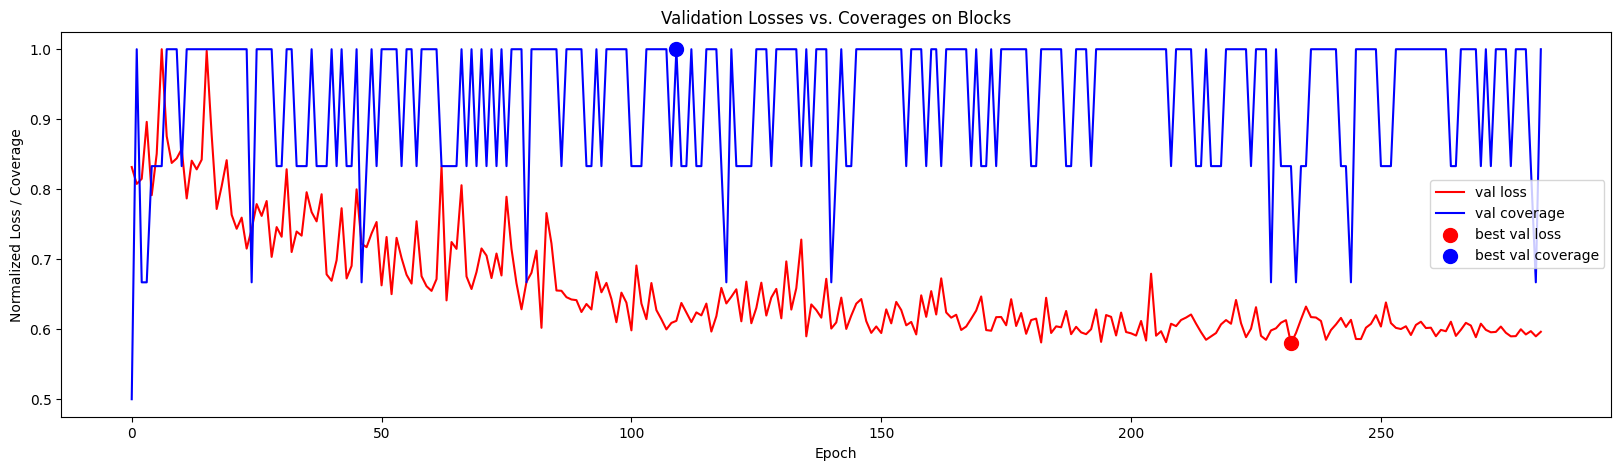

In [3]:
experiment_path = "/Users/nicola_mueller/Desktop/new_graph_representation/new_gcn_blocks/trained/round_0/version_1"
plot_losses_vs_coverages(experiment_path, "Blocks")

Correlation between normalized val losses and val coverages:  -0.23051425751873744


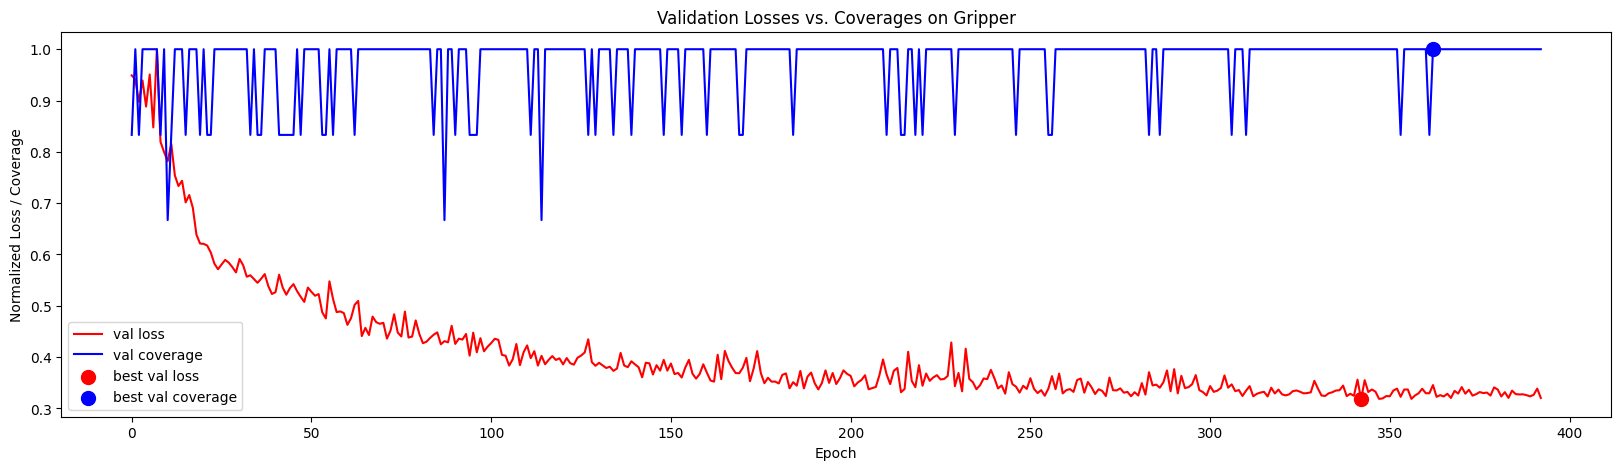

In [4]:
experiment_path = "/Users/nicola_mueller/Desktop/new_graph_representation/new_gcn_gripper/trained/round_0/version_1"
plot_losses_vs_coverages(experiment_path, "Gripper")

Correlation between normalized val losses and val coverages:  -0.4399221845228579


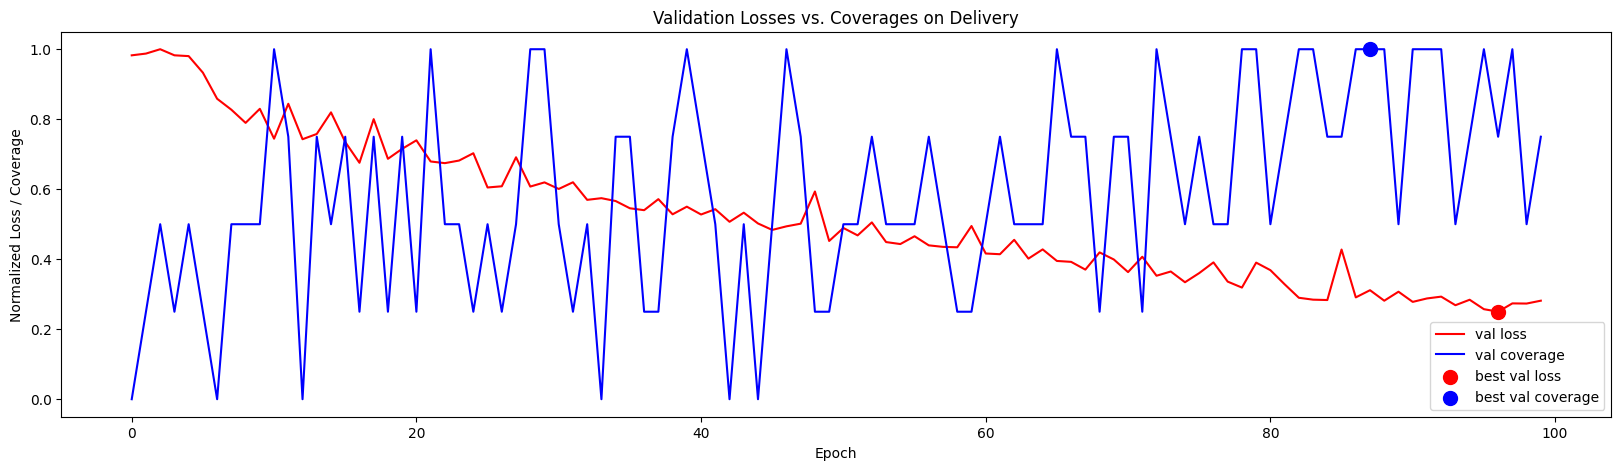

In [5]:
experiment_path = "/Users/nicola_mueller/Desktop/new_graph_representation/new_gcn_parking/trained/round_0/version_0"
plot_losses_vs_coverages(experiment_path, "Delivery")

Correlation between normalized val losses and val coverages:  -0.5025825943878169


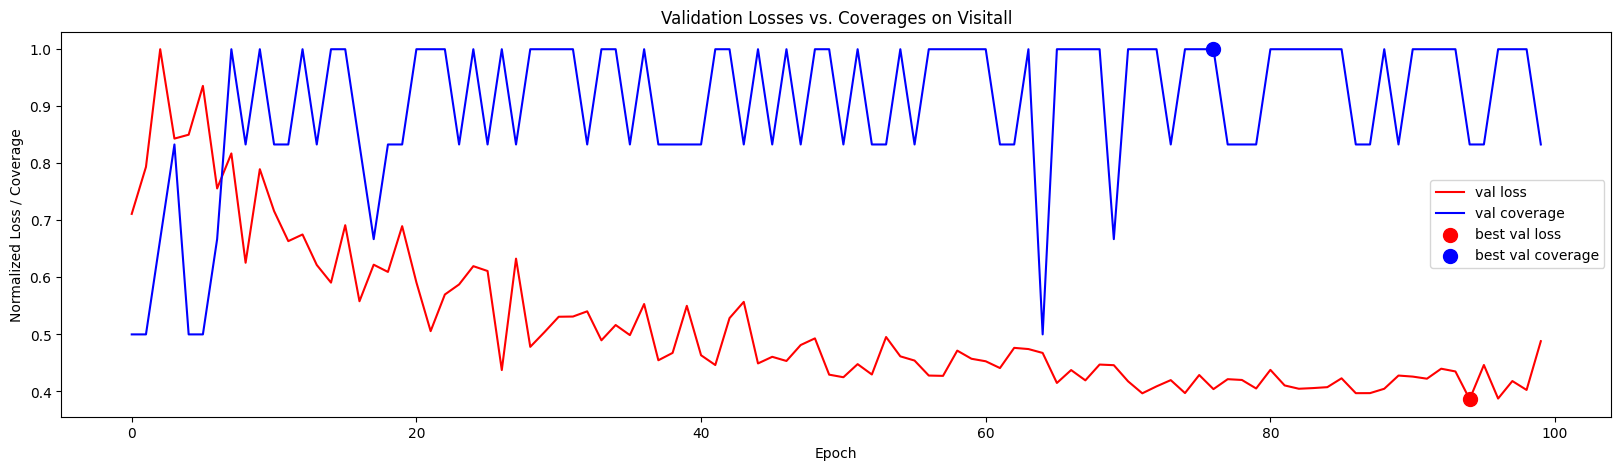

In [6]:
experiment_path = "/Users/nicola_mueller/Desktop/new_graph_representation/new_gcn_visitall/config_0/trained/round_0/version_0"
plot_losses_vs_coverages(experiment_path, "Visitall")

Correlation between normalized val losses and val coverages:  -0.36778549758961526


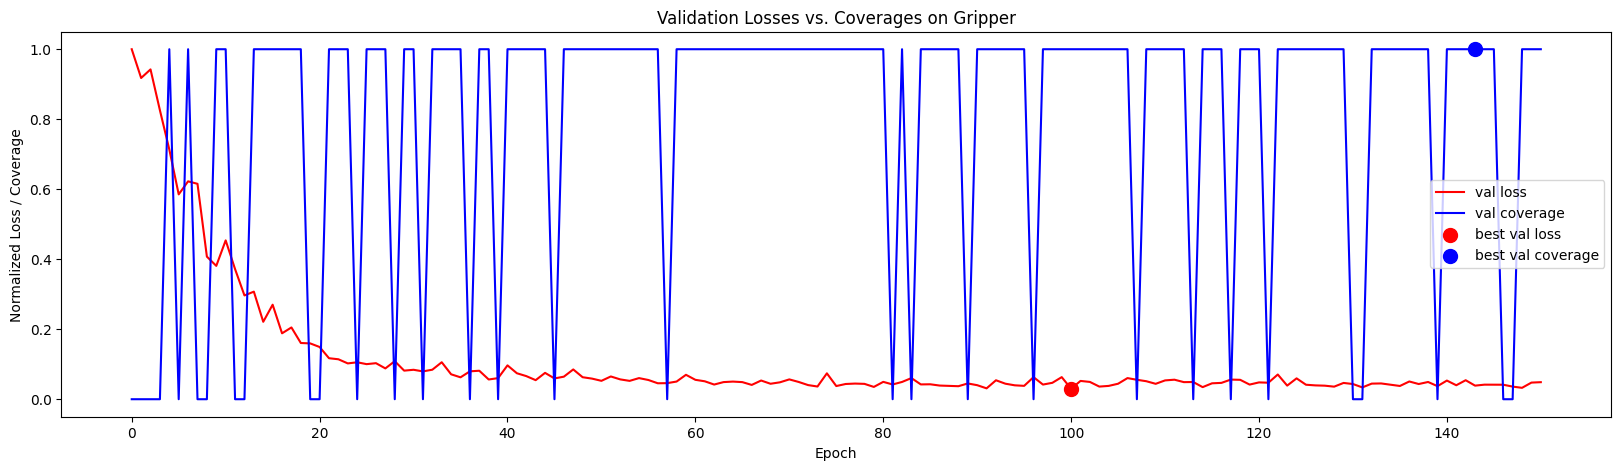

In [7]:
experiment_path = "/Users/nicola_mueller/Desktop/new_graph_representation/tune_new_gcn_gripper2/config_0/trained/version_0"
plot_losses_vs_coverages(experiment_path, "Gripper")